In [1]:
# statistical_analysis.py
# Simple stats workflow:
# 1) z-scores within seed + boxplots
# 2) Friedman ANOVA (>=3 configs)
# 3) Wilcoxon signed-rank post-hoc (pairwise between configs, Bonferroni)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats


# ----------------------------
# 1) Z-scores + boxplots
# ----------------------------
def zscores_and_boxplots(df, seed_col, config_col, configs, measures, make_plots=True):
    """
    - Filters df to selected configs
    - Keeps only seeds present in all configs (paired)
    - Computes z-scores per seed (across configs) for each measure
    - Optionally plots boxplots per measure (one plot per measure)
    Returns: d (filtered df with <measure>_z columns), wide_tables (dict measure->wide z table)
    """
    d = df[df[config_col].isin(configs)].copy()
    d[seed_col] = d[seed_col].astype(str)

    common_seeds = set.intersection(*[set(d.loc[d[config_col] == c, seed_col]) for c in configs])
    d = d[d[seed_col].isin(common_seeds)].copy()

    for m in measures:
        d[m] = pd.to_numeric(d[m], errors="coerce")
        mu = d.groupby(seed_col)[m].transform("mean")
        sd = d.groupby(seed_col)[m].transform(lambda x: x.std(ddof=0))
        d[m + "_z"] = (d[m] - mu) / sd.replace(0, np.nan)

    wide_tables = {}
    for m in measures:
        zc = m + "_z"
        wide = d.pivot_table(index=seed_col, columns=config_col, values=zc, aggfunc="mean")
        wide = wide[configs].dropna(axis=0, how="any")
        wide_tables[m] = wide

        if make_plots:
            groups = [wide[c].to_numpy() for c in wide.columns]
            plt.figure(figsize=(12, 4))
            plt.boxplot(groups, labels=list(wide.columns), showmeans=True)
            plt.axhline(0.0, linestyle="--")
            plt.title(f"{m} (z-scores within seed)")
            plt.ylabel("z-score [-]")
            plt.xticks(rotation=35, ha="right")
            plt.tight_layout()
            plt.show()

    return d, wide_tables


# ----------------------------
# 2) Friedman ANOVA
# ----------------------------
def friedman_anova(df, seed_col, config_col, configs, measures, use_zscores=True):
    """
    - Filters df to selected configs
    - Keeps only paired seeds across configs
    - Runs Friedman per measure
    Returns: friedman_results (DataFrame), wide_tables (dict measure->wide table used)
    """
    d = df[df[config_col].isin(configs)].copy()
    d[seed_col] = d[seed_col].astype(str)

    common_seeds = set.intersection(*[set(d.loc[d[config_col] == c, seed_col]) for c in configs])
    d = d[d[seed_col].isin(common_seeds)].copy()

    if use_zscores:
        for m in measures:
            d[m] = pd.to_numeric(d[m], errors="coerce")
            mu = d.groupby(seed_col)[m].transform("mean")
            sd = d.groupby(seed_col)[m].transform(lambda x: x.std(ddof=0))
            d[m + "_z"] = (d[m] - mu) / sd.replace(0, np.nan)

    rows = []
    wide_tables = {}

    for m in measures:
        col = (m + "_z") if use_zscores else m
        wide = d.pivot_table(index=seed_col, columns=config_col, values=col, aggfunc="mean")
        wide = wide[configs].dropna(axis=0, how="any")
        wide_tables[m] = wide

        arrays = [wide[c].to_numpy() for c in wide.columns]
        chi2, p = stats.friedmanchisquare(*arrays)

        n, k = wide.shape
        W = chi2 / (n * (k - 1))  # Kendall's W
        df_chi2 = k - 1

        rows.append({
            "measure": m,
            "chi2": float(chi2),
            "df": int(df_chi2),
            "p": float(p),
            "n": int(n),
            "k": int(k),
            "kendall_W": float(W),
        })

    friedman_results = pd.DataFrame(rows).sort_values("p")
    return friedman_results, wide_tables


# ----------------------------
# 3) Wilcoxon post-hoc (pairwise)
# ----------------------------
def wilcoxon_posthoc(df, seed_col, config_col, configs, measures, use_zscores=True, correction="bonferroni"):
    """
    - Filters df to selected configs
    - Keeps only paired seeds across configs
    - Runs pairwise Wilcoxon signed-rank per measure
    - Bonferroni by default: p_adj = p_raw * (#pairs)
    Returns: posthoc_results (DataFrame)
    """
    d = df[df[config_col].isin(configs)].copy()
    d[seed_col] = d[seed_col].astype(str)

    common_seeds = set.intersection(*[set(d.loc[d[config_col] == c, seed_col]) for c in configs])
    d = d[d[seed_col].isin(common_seeds)].copy()

    if use_zscores:
        for m in measures:
            d[m] = pd.to_numeric(d[m], errors="coerce")
            mu = d.groupby(seed_col)[m].transform("mean")
            sd = d.groupby(seed_col)[m].transform(lambda x: x.std(ddof=0))
            d[m + "_z"] = (d[m] - mu) / sd.replace(0, np.nan)

    pairs = [(configs[i], configs[j]) for i in range(len(configs)) for j in range(i + 1, len(configs))]
    n_pairs = len(pairs)

    rows = []
    for m in measures:
        col = (m + "_z") if use_zscores else m
        wide = d.pivot_table(index=seed_col, columns=config_col, values=col, aggfunc="mean")
        wide = wide[configs].dropna(axis=0, how="any")

        for a, b in pairs:
            x = wide[a].to_numpy()
            y = wide[b].to_numpy()

            stat, p = stats.wilcoxon(x, y)
            rows.append({
                "measure": m,
                "A": a,
                "B": b,
                "stat": float(stat),
                "p_raw": float(p),
                "n": int(len(x)),
                "median_diff": float(np.median(x - y)),
                "mean_diff": float(np.mean(x - y)),
            })

    posthoc = pd.DataFrame(rows)

    if correction == "bonferroni":
        posthoc["p_adj"] = posthoc["p_raw"] * n_pairs
    else:
        posthoc["p_adj"] = posthoc["p_raw"]

    return posthoc.sort_values(["measure", "p_adj", "p_raw"])

In [2]:
# === Cell 2: load ALL pickles from folder -> single DataFrame ===
from pathlib import Path
import pickle

PICKLE_DIR = Path("/Users/jornvanbeek/Desktop/bluesky/Montecarlo")  # <-- map met pickles
PICKLE_DIR = Path('/Users/jornvanbeek/Desktop/bluesky/Montecarlo/old_errorgenerator')
DF_KEY = None  # bv "results_df" als elke pickle een dict is

def load_pickle(path: Path):
    with path.open("rb") as f:
        return pickle.load(f)

dfs = []

pickle_files = sorted(PICKLE_DIR.glob("*.pkl")) + sorted(PICKLE_DIR.glob("*.pickle"))
if not pickle_files:
    raise FileNotFoundError(f"No pickle files found in {PICKLE_DIR}")

for pkl in pickle_files:
    obj = load_pickle(pkl)

    # --- haal DataFrame uit pickle ---
    if isinstance(obj, pd.DataFrame):
        df_i = obj.copy()

    elif isinstance(obj, dict):
        if DF_KEY is not None:
            if DF_KEY not in obj or not isinstance(obj[DF_KEY], pd.DataFrame):
                raise KeyError(f"{pkl.name}: DF_KEY={DF_KEY!r} not found")
            df_i = obj[DF_KEY].copy()
        else:
            for k in ("results_df", "results", "df", "data"):
                if k in obj and isinstance(obj[k], pd.DataFrame):
                    df_i = obj[k].copy()
                    break
            else:
                raise KeyError(f"{pkl.name}: no DataFrame key found")

    else:
        raise TypeError(f"{pkl.name}: unsupported pickle content {type(obj)}")

    # --- voeg configuratie-label toe ---
    # standaard: bestandsnaam zonder extensie
    df_i["config"] = pkl.stem

    dfs.append(df_i)

# combineer alles
df = pd.concat(dfs, ignore_index=True)

print(f"Loaded {len(dfs)} pickles")
print("Combined shape:", df.shape)
print("Configs:", df["config"].unique())


Loaded 15 pickles
Combined shape: (850, 84)
Configs: ['SCENARIOTEST_DELAY20' 'SCENARIOTEST_DELAY20CERTAIN'
 'SCENARIOTEST_DELAY20NOPOPUP' 'SCENARIOTEST_DELAY20_highseed'
 'SCENARIOTEST_DELAY20_rate38' 'SCENARIOTEST_DELAY25'
 'SCENARIOTEST_FCFS14' 'SCENARIOTEST_FCFS14_NOPOPUP'
 'SCENARIOTEST_FCFS14_highseed' 'SCENARIOTEST_FCFS20'
 'SCENARIOTEST_FCFS20CERTAIN' 'SCENARIOTEST_FCFS20NOPOPUP'
 'SCENARIOTEST_FCFS20_highseed' 'SCENARIOTEST_FCFS20_rate38'
 'SCENARIOTEST_FCFS25']


In [3]:
df.columns

Index(['scenario', 'run', 'seed', 'usecache', 'node', 'status', 'maxtime',
       'starttime', 'endtime', 'elapsed', 'mean_pct_extrawork',
       'freezehorizon', 'popup_planner', 'error_multiplicator', 'capacity',
       'pct_count_eq_0', 'mean_count', 'mean_count_nonzero', 'max_count',
       'second_highest_count', 'max_count_acid', 'min_count_holding',
       'mean_count_holding', 'max_count_holding', 'count_popup',
       'count_fh_margin_at_freeze', 'min_fh_margin_at_freeze',
       'mean_fh_margin_at_freeze', 'max_fh_margin_at_freeze',
       'min_EAT_updates', 'mean_EAT_updates', 'max_EAT_updates',
       'mean_EAT_updates_nonzero', 'min_swaps', 'mean_swaps', 'max_swaps',
       'mean_swaps_nonzero', 'amount_of_swaps', 'min_ttlg_at_freeze',
       'mean_ttlg_at_freeze', 'median_ttlg_at_freeze', 'max_ttlg_at_freeze',
       'mean_abs_ttlg_at_freeze', 'mean_E_TO', 'mean_abs_E_TO', 'min_E_TO',
       'max_E_TO', 'mean_totaldelay', 'max_totaldelay',
       'mean_totaldelay_nonzero'

/var/folders/0v/cqt77j_s3c30c4jmmxgy9_m40000gn/T/ipykernel_90863/687880714.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=list(wide.columns), showmeans=True)


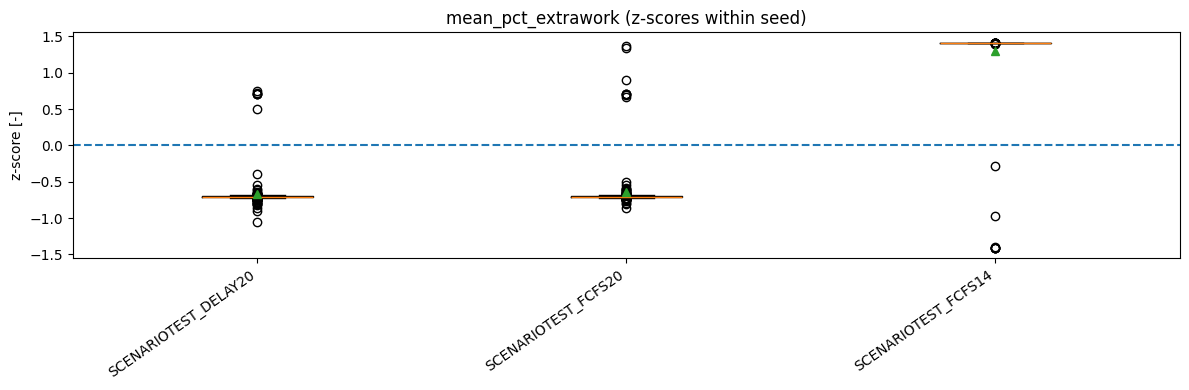

/var/folders/0v/cqt77j_s3c30c4jmmxgy9_m40000gn/T/ipykernel_90863/687880714.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=list(wide.columns), showmeans=True)


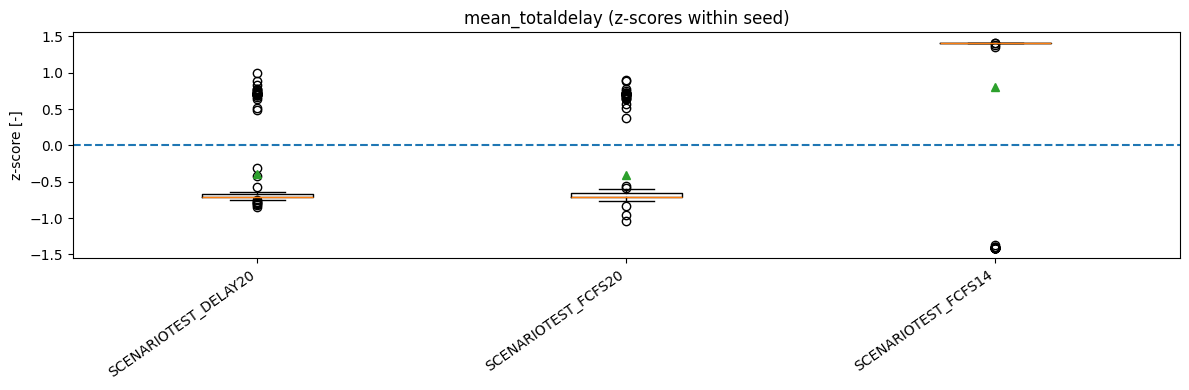

/var/folders/0v/cqt77j_s3c30c4jmmxgy9_m40000gn/T/ipykernel_90863/687880714.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=list(wide.columns), showmeans=True)


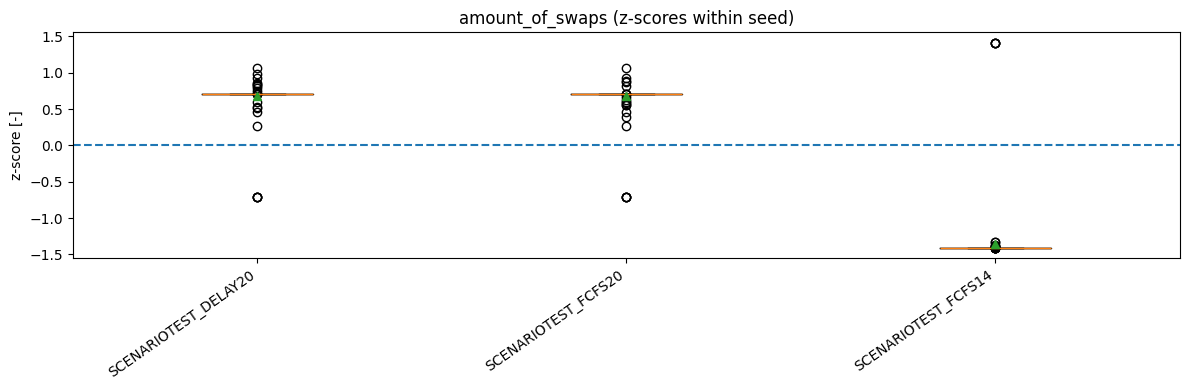

/var/folders/0v/cqt77j_s3c30c4jmmxgy9_m40000gn/T/ipykernel_90863/687880714.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=list(wide.columns), showmeans=True)


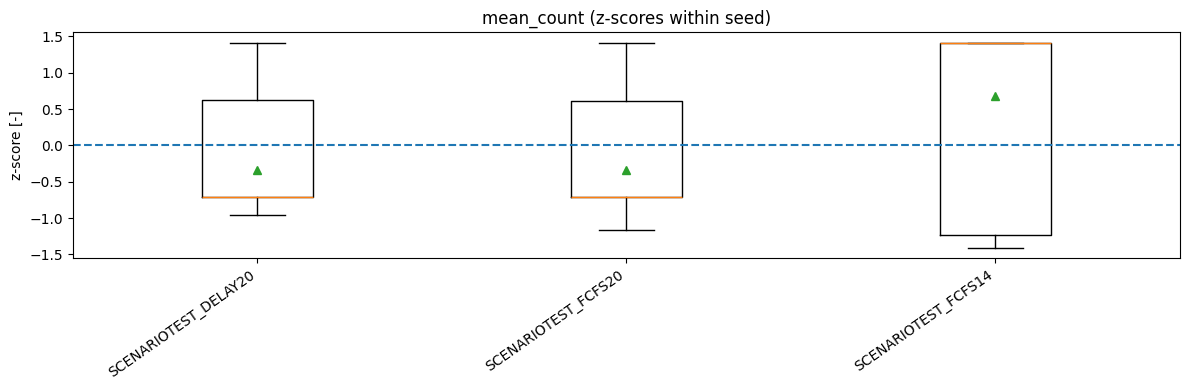


Friedman:
               measure        chi2  df             p    n  k  kendall_W
2     amount_of_swaps  330.414763   2  1.783799e-72  185  3   0.893013
0  mean_pct_extrawork  243.643979   2  1.239887e-53  191  3   0.637811
1     mean_totaldelay   99.861601   2  2.066945e-22  191  3   0.261418
3          mean_count   81.238562   2  2.287022e-18  190  3   0.213786

Post-hoc Wilcoxon:
                measure                     A                    B    stat  \
7      amount_of_swaps  SCENARIOTEST_DELAY20  SCENARIOTEST_FCFS14   349.5   
8      amount_of_swaps   SCENARIOTEST_FCFS20  SCENARIOTEST_FCFS14   365.5   
6      amount_of_swaps  SCENARIOTEST_DELAY20  SCENARIOTEST_FCFS20    44.5   
10          mean_count  SCENARIOTEST_DELAY20  SCENARIOTEST_FCFS14  4784.5   
11          mean_count   SCENARIOTEST_FCFS20  SCENARIOTEST_FCFS14  4808.0   
9           mean_count  SCENARIOTEST_DELAY20  SCENARIOTEST_FCFS20   473.5   
1   mean_pct_extrawork  SCENARIOTEST_DELAY20  SCENARIOTEST_FCFS14   584.0

In [8]:
seed_col = "seed"
config_col = "scenario"

# --- select configs to compare (ordered) ---
configs = [
    "SCENARIOTEST_DELAY20",
    "SCENARIOTEST_FCFS20",
    "SCENARIOTEST_FCFS14",
]

# --- measures ---
measures = [
    'mean_pct_extrawork',
    'mean_totaldelay',
    'amount_of_swaps',
    'mean_count'
]

# 1) z-scores + boxplots
d_z, wide_z = zscores_and_boxplots(
    df, seed_col=seed_col, config_col=config_col,
    configs=configs, measures=measures,
    make_plots=True
)

# 2) friedman
friedman_results, wide_f = friedman_anova(
    df, seed_col=seed_col, config_col=config_col,
    configs=configs, measures=measures,
    use_zscores=True
)
print("\nFriedman:\n", friedman_results)

# 3) wilcoxon post-hoc
posthoc = wilcoxon_posthoc(
    df, seed_col=seed_col, config_col=config_col,
    configs=configs, measures=measures,
    use_zscores=True,
    correction="bonferroni"
)
print("\nPost-hoc Wilcoxon:\n", posthoc)